# v2 四模型正式结果比较

本 notebook 比较 `fno`、`fno_gamma`、`shared_oracle` 与 `shared_oracle_rho0` 的五 seed 正式结果。所有统计都从逐样本产物重新计算；预注册主比较仍为 $N=256$ 上 `shared_oracle - fno_gamma` 的逐样本相对 $L_2$。固定 $\rho=0$ 模型作为后注册消融，重点比较 `shared_oracle_rho0 - shared_oracle`。所有区间使用 10,000 次 seed/样本分层配对 bootstrap。


## 1. 比较契约

- 主比较：Oracle-Shared 相对 FNO+$\gamma_T$ 的结构增益。
- 原协议次要比较：FNO+$\gamma_T$ 相对 FNO 的先验增益；Oracle-Shared 相对 FNO 的联合增益。
- 后注册消融：固定 $\rho=0$ 的 Oracle-Shared 相对可学习 $\rho$ 的 Oracle-Shared，并补充它相对 FNO+$\gamma_T$ 和 FNO 的差异。
- 四个模型均比较 $N=512$ 与 $N=1024$ 的零样本超分辨率。
- 差值方向统一为“前者减后者”；误差指标的负值表示前者更好。
- 图内使用英文标签以避免服务器字体差异，notebook 说明和自动报告使用中文。
- 所有定量图导出 SVG、PDF、600 dpi TIFF 与 300 dpi PNG，并保留 source-data CSV。


## 2. 环境、路径与绘图样式


In [1]:
import csv
import hashlib
import json
import math
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

current_directory = Path.cwd().resolve()
repository_root = next(
    candidate
    for candidate in (current_directory, *current_directory.parents)
    if (candidate / "deep_fno_shared_benchmark" / "experiment.py").is_file()
)
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

from deep_fno_shared_benchmark.formal_v2 import find_repository_root

repository_root = find_repository_root(repository_root)
project_dir = repository_root / "deep_fno_shared_benchmark"
results_root = project_dir / "results" / "formal_main_v2"
comparison_dir = results_root / "comparison_four_models"
figure_dir = comparison_dir / "figures"
source_dir = comparison_dir / "source_data"
figure_dir.mkdir(parents=True, exist_ok=True)
source_dir.mkdir(parents=True, exist_ok=True)

MODELS = ("fno", "fno_gamma", "shared_oracle", "shared_oracle_rho0")
MODEL_LABELS = {
    "fno": "FNO",
    "fno_gamma": r"FNO+$\gamma_T$",
    "shared_oracle": "Oracle-Shared",
    "shared_oracle_rho0": r"Oracle-Shared ($\rho=0$)",
}
COLORS = {
    "fno": "#4C78A8",
    "fno_gamma": "#F2A541",
    "shared_oracle": "#009E73",
    "shared_oracle_rho0": "#CC79A7",
}
SEEDS = (0, 1, 2, 3, 4)
RESOLUTIONS = (256, 512, 1024)
PRIMARY_RESOLUTION = 256
BOOTSTRAP_REPETITIONS = 10_000
CONTRASTS = (
    ("shared_oracle_minus_fno_gamma", "shared_oracle", "fno_gamma", "Structure gain"),
    ("fno_gamma_minus_fno", "fno_gamma", "fno", "Prior-information gain"),
    ("shared_oracle_minus_fno", "shared_oracle", "fno", "Joint gain"),
    (
        "shared_oracle_rho0_minus_shared_oracle",
        "shared_oracle_rho0",
        "shared_oracle",
        r"Fixed $\rho=0$ minus learned $\rho$",
    ),
    (
        "shared_oracle_rho0_minus_fno_gamma",
        "shared_oracle_rho0",
        "fno_gamma",
        r"Fixed-$\rho$ structure gain",
    ),
    (
        "shared_oracle_rho0_minus_fno",
        "shared_oracle_rho0",
        "fno",
        r"Fixed-$\rho$ joint gain",
    ),
)
METRICS = (
    ("relative_l2", r"Relative $L_2$"),
    ("mse", "MSE"),
    ("interface_mae", "Interface MAE"),
    ("jump_amplitude_error", "Jump-amplitude error"),
    ("total_variation_error", "TV error"),
    ("overshoot", "Overshoot"),
    ("undershoot", "Undershoot"),
    ("high_frequency_absolute_error", "HF absolute error"),
    ("high_frequency_relative_error", "HF relative error"),
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "legend.fontsize": 6.5,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.7,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

def export_figure(figure, name):
    for extension, kwargs in (
        ("svg", {}), ("pdf", {}), ("tiff", {"dpi": 600}), ("png", {"dpi": 300})
    ):
        figure.savefig(figure_dir / f"{name}.{extension}", bbox_inches="tight", **kwargs)

def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

def read_csv(path):
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def run_dir(model, seed):
    return results_root / model / f"seed_{seed}_run" / f"seed_{seed}" / model

def seed_dir(model, seed):
    return results_root / model / f"seed_{seed}_run"

def metadata_from_checkpoint(path):
    with np.load(path, allow_pickle=False) as saved:
        return json.loads(str(saved["metadata_json"]))

print("结果目录：", results_root)


结果目录： D:\A4S\间断问题\deep_fno_shared_benchmark\results\formal_main_v2


## 3. 正式产物审计

比较开始前逐模型、逐 seed 检查 v2 协议、500 行 history、最佳与最终 checkpoint、三种分辨率、测试样本配对关系，以及解析 $\gamma_T$ 与第四输入通道/Oracle 门控的一致性。对 `shared_oracle_rho0` 还检查参数树中没有 `rho_eta`、各层 $\rho$ 全为零。


In [2]:
summary_lookup = {}
history_lookup = {}
reference_digest = {}
audit_rows = []

for model in MODELS:
    aggregate = read_json(results_root / model / "aggregate_manifest.json")
    assert aggregate["protocol_version"] == 2
    assert aggregate["run_tag"] == "main_v2"
    assert aggregate["epochs"] == 500
    for seed in SEEDS:
        seed_output = seed_dir(model, seed)
        manifest = read_json(seed_output / "manifest.json")
        assert manifest["protocol_version"] == 2
        assert manifest["run_tag"] == "main_v2"
        assert manifest["models"] == [model]
        assert manifest["training_config"]["epochs"] == 500
        assert manifest["training_config"]["early_stopping"] is False
        assert manifest["training_config"]["gamma_loss_weight"] == 0.0
        assert manifest["sizes"] == {"train": 16000, "validation": 2000, "test": 4000}

        current_run = run_dir(model, seed)
        history = read_csv(current_run / "history.csv")
        if len(history) != 500:
            raise RuntimeError(f"{model} seed={seed} 的 history 不是 500 行")
        history_lookup[(model, seed)] = history
        best_row = min(history, key=lambda row: float(row["validation_relative_l2"]))
        best_meta = metadata_from_checkpoint(current_run / "checkpoint_best.npz")
        final_meta = metadata_from_checkpoint(current_run / "checkpoint_final.npz")
        assert best_meta["best_epoch"] == int(float(best_row["epoch"]))
        assert final_meta["epoch"] == 500

        for row in read_csv(seed_output / "summary.csv"):
            resolution = int(row["resolution"])
            summary_lookup[(model, seed, resolution)] = row
            prediction_path = current_run / f"predictions_n{resolution}.npz"
            with np.load(prediction_path, allow_pickle=False) as saved:
                digest = hashlib.sha256()
                for key in ("sample_id", "target", "gamma_target", "jump", "interface_location"):
                    digest.update(np.asarray(saved[key]).tobytes())
                current_digest = digest.hexdigest()
                reference_digest.setdefault(resolution, current_digest)
                if current_digest != reference_digest[resolution]:
                    raise RuntimeError(f"测试样本未配对：{model} seed={seed} N={resolution}")
                if model in {"fno_gamma", "shared_oracle", "shared_oracle_rho0"}:
                    np.testing.assert_array_equal(saved["gamma_input"], saved["gamma_target"])
                if "gamma_mse" in saved.files or "false_jump" in saved.files:
                    raise RuntimeError("v2 产物混入了已删除的 gamma/连续样本指标")
        metrics = read_json(current_run / "metrics.json")
        if model in {"shared_oracle", "shared_oracle_rho0"}:
            for resolution in RESOLUTIONS:
                assert metrics[str(resolution)]["oracle_gate_max_abs_error"] == 0.0
        if model == "shared_oracle_rho0":
            assert manifest["model_config"]["rho_mode"] == "fixed_zero"
            assert manifest["rho_policy"][model] == "fixed_zero_non_trainable"
            assert all(
                metrics[str(resolution)]["rho_fixed_zero_max_abs_error"] == 0.0
                for resolution in RESOLUTIONS
            )
            with np.load(current_run / "checkpoint_best.npz", allow_pickle=False) as saved:
                if any("rho_eta" in str(path) for path in saved["paths"]):
                    raise RuntimeError("固定 rho=0 checkpoint 中出现了可训练 rho_eta")
            with np.load(current_run / "rho_layers.npz", allow_pickle=False) as saved:
                for name in saved.files:
                    np.testing.assert_array_equal(saved[name], np.zeros_like(saved[name]))
        audit_rows.append({
            "model": model,
            "seed": seed,
            "history_rows": len(history),
            "best_epoch": best_meta["best_epoch"],
            "final_epoch": final_meta["epoch"],
            "gamma_integrity": "pass" if model != "fno" else "not_applicable",
            "rho_policy": manifest.get("rho_policy", {}).get(model, "not_applicable"),
        })

pd.DataFrame(audit_rows).to_csv(source_dir / "artifact_audit.csv", index=False)
display(pd.DataFrame(audit_rows))
print("PASS：20 个正式训练单元的协议、配对关系和 checkpoint 语义均通过审计。")


,model,seed,history_rows,best_epoch,final_epoch,gamma_integrity,rho_policy
0,fno,0,500,498,500,not_applicable,not_applicable
1,fno,1,500,500,500,not_applicable,not_applicable
2,fno,2,500,495,500,not_applicable,not_applicable
3,fno,3,500,497,500,not_applicable,not_applicable
4,fno,4,500,500,500,not_applicable,not_applicable
5,fno_gamma,0,500,499,500,pass,not_applicable
6,fno_gamma,1,500,493,500,pass,not_applicable
7,fno_gamma,2,500,495,500,pass,not_applicable
8,fno_gamma,3,500,497,500,pass,not_applicable
9,fno_gamma,4,500,500,500,pass,not_applicable


PASS：20 个正式训练单元的协议、配对关系和 checkpoint 语义均通过审计。


## 4. 指标矩阵与分层配对 bootstrap

主分辨率对九项误差指标执行四模型全部六组两两配对比较；两个超分辨率对相对 $L_2$ 执行同样比较。每次 bootstrap 先有放回抽取五个训练 seed，再在每个被抽中的 seed 内有放回抽取共享测试样本。


In [3]:
metric_data = {}
for resolution in RESOLUTIONS:
    metric_data[resolution] = {}
    for model in MODELS:
        by_seed = []
        for seed in SEEDS:
            with np.load(run_dir(model, seed) / f"predictions_n{resolution}.npz", allow_pickle=False) as saved:
                by_seed.append(np.stack([np.asarray(saved[key], dtype=np.float64) for key, _ in METRICS], axis=-1))
        metric_data[resolution][model] = np.stack(by_seed, axis=0)

def hierarchical_bootstrap_many(values, repetitions=10_000, seed=0, chunk_size=5):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 3:
        raise ValueError("values 必须为 [seeds, samples, metrics]")
    n_seeds, n_samples, n_metrics = values.shape
    estimates = np.empty((repetitions, n_metrics), dtype=np.float64)
    rng = np.random.default_rng(seed)
    for start in tqdm(range(0, repetitions, chunk_size), desc="hierarchical bootstrap"):
        stop = min(start + chunk_size, repetitions)
        count = stop - start
        seed_indices = rng.integers(0, n_seeds, size=(count, n_seeds))
        sample_indices = rng.integers(0, n_samples, size=(count, n_seeds, n_samples))
        selected = values[seed_indices]
        selected = np.take_along_axis(selected, sample_indices[..., None], axis=2)
        estimates[start:stop] = np.nanmean(selected, axis=(1, 2))
    return np.nanmean(values, axis=(0, 1)), estimates

bootstrap_rows = []
model_index = {model: index for index, model in enumerate(MODELS)}
for resolution in RESOLUTIONS:
    selected_metric_indices = list(range(len(METRICS))) if resolution == 256 else [0]
    combined = np.concatenate(
        [metric_data[resolution][model][:, :, selected_metric_indices] for model in MODELS],
        axis=-1,
    )
    model_means, model_estimates = hierarchical_bootstrap_many(
        combined,
        repetitions=BOOTSTRAP_REPETITIONS,
        seed=20260721 + resolution,
        chunk_size=5,
    )
    model_means = model_means.reshape(len(MODELS), len(selected_metric_indices))
    model_estimates = model_estimates.reshape(
        BOOTSTRAP_REPETITIONS, len(MODELS), len(selected_metric_indices)
    )
    for contrast_index, (contrast_name, left, right, contrast_label) in enumerate(CONTRASTS):
        left_index = model_index[left]
        right_index = model_index[right]
        means = model_means[left_index] - model_means[right_index]
        bootstrap_differences = (
            model_estimates[:, left_index] - model_estimates[:, right_index]
        )
        intervals = np.nanquantile(bootstrap_differences, [0.025, 0.975], axis=0)
        for local_index, metric_index in enumerate(selected_metric_indices):
            metric_key, metric_label = METRICS[metric_index]
            left_mean = float(np.nanmean(metric_data[resolution][left][:, :, metric_index]))
            right_mean = float(np.nanmean(metric_data[resolution][right][:, :, metric_index]))
            bootstrap_rows.append({
                "resolution": resolution,
                "contrast": contrast_name,
                "contrast_label": contrast_label,
                "left_model": left,
                "right_model": right,
                "metric": metric_key,
                "metric_label": metric_label,
                "left_mean": left_mean,
                "right_mean": right_mean,
                "difference": float(means[local_index]),
                "lower_95": float(intervals[0, local_index]),
                "upper_95": float(intervals[1, local_index]),
                "percent_change": 100.0 * float(means[local_index]) / max(abs(right_mean), 1e-15),
                "repetitions": BOOTSTRAP_REPETITIONS,
            })

bootstrap_frame = pd.DataFrame(bootstrap_rows)
bootstrap_frame.to_csv(source_dir / "paired_hierarchical_bootstrap.csv", index=False)
display(bootstrap_frame)


hierarchical bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,resolution,contrast,contrast_label,left_model,right_model,metric,metric_label,left_mean,right_mean,difference,lower_95,upper_95,percent_change,repetitions
0,256,shared_oracle_minus_fno_gamma,Structure gain,shared_oracle,fno_gamma,relative_l2,Relative $L_2$,0.038618,0.040690,-0.002072,-0.007557,0.001971,-5.092566,10000
1,256,shared_oracle_minus_fno_gamma,Structure gain,shared_oracle,fno_gamma,mse,MSE,0.000434,0.000497,-0.000063,-0.000194,0.000034,-12.717687,10000
2,256,shared_oracle_minus_fno_gamma,Structure gain,shared_oracle,fno_gamma,interface_mae,Interface MAE,0.022723,0.027503,-0.004779,-0.007273,-0.002242,-17.377726,10000
3,256,shared_oracle_minus_fno_gamma,Structure gain,shared_oracle,fno_gamma,jump_amplitude_error,Jump-amplitude error,0.020944,0.025942,-0.004998,-0.006780,-0.003295,-19.267058,10000
4,256,shared_oracle_minus_fno_gamma,Structure gain,shared_oracle,fno_gamma,total_variation_error,TV error,0.946822,0.579596,0.367226,0.164742,0.497930,63.358862,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,1024,fno_gamma_minus_fno,Prior-information gain,fno_gamma,fno,relative_l2,Relative $L_2$,0.225533,0.166180,0.059353,-0.014604,0.153098,35.716229,10000
62,1024,shared_oracle_minus_fno,Joint gain,shared_oracle,fno,relative_l2,Relative $L_2$,0.041927,0.166180,-0.124252,-0.153055,-0.095991,-74.769817,10000
63,1024,shared_oracle_rho0_minus_shared_oracle,Fixed $\rho=0$ minus learned $\rho$,shared_oracle_rho0,shared_oracle,relative_l2,Relative $L_2$,0.043399,0.041927,0.001471,-0.000696,0.003474,3.508657,10000
64,1024,shared_oracle_rho0_minus_fno_gamma,Fixed-$\rho$ structure gain,shared_oracle_rho0,fno_gamma,relative_l2,Relative $L_2$,0.043399,0.225533,-0.182134,-0.268459,-0.106729,-80.757332,10000


## 5. 图 1：主比较、原协议次要比较与固定 $\rho=0$ 消融


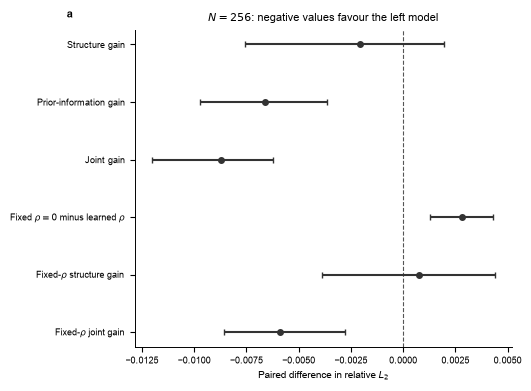

In [4]:
primary_rows = bootstrap_frame[(bootstrap_frame.resolution == 256) & (bootstrap_frame.metric == "relative_l2")].copy()
primary_rows["order"] = primary_rows["contrast"].map({name: index for index, (name, *_rest) in enumerate(CONTRASTS)})
primary_rows = primary_rows.sort_values("order")

figure, axis = plt.subplots(figsize=(5.2, 3.8), constrained_layout=True)
y = np.arange(len(primary_rows))
axis.axvline(0.0, color="#555555", linestyle="--", linewidth=0.8)
axis.errorbar(
    primary_rows["difference"], y,
    xerr=np.vstack([primary_rows["difference"] - primary_rows["lower_95"], primary_rows["upper_95"] - primary_rows["difference"]]),
    fmt="o", color="#333333", ecolor="#333333", capsize=2.5, markersize=4,
)
axis.set_yticks(y, primary_rows["contrast_label"])
axis.invert_yaxis()
axis.set_xlabel(r"Paired difference in relative $L_2$")
axis.set_title(r"$N=256$: negative values favour the left model")
axis.spines[["top", "right"]].set_visible(False)
axis.text(-0.18, 1.04, "a", transform=axis.transAxes, fontweight="bold", fontsize=8)
export_figure(figure, "figure1_primary_contrasts")
plt.show()
primary_rows.to_csv(source_dir / "figure1_primary_contrasts.csv", index=False)


## 6. 图 2：零样本超分辨率


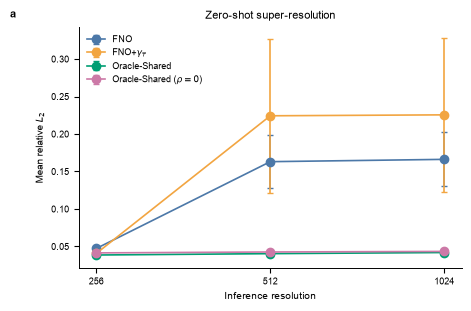

In [5]:
resolution_rows = []
figure, axis = plt.subplots(figsize=(4.6, 3.0), constrained_layout=True)
for model in MODELS:
    means, stds = [], []
    for resolution in RESOLUTIONS:
        values = np.asarray([float(summary_lookup[(model, seed, resolution)]["relative_l2_mean"]) for seed in SEEDS])
        means.append(values.mean())
        stds.append(values.std(ddof=1))
        for seed, value in zip(SEEDS, values, strict=True):
            resolution_rows.append({"model": model, "seed": seed, "resolution": resolution, "relative_l2_mean": value})
    axis.errorbar(RESOLUTIONS, means, yerr=stds, marker="o", capsize=2.5, linewidth=1.2, color=COLORS[model], label=MODEL_LABELS[model])
axis.set_xscale("log", base=2)
axis.set_xticks(RESOLUTIONS, [str(value) for value in RESOLUTIONS])
axis.set_xlabel("Inference resolution")
axis.set_ylabel(r"Mean relative $L_2$")
axis.set_title("Zero-shot super-resolution")
axis.legend(frameon=False)
axis.spines[["top", "right"]].set_visible(False)
axis.text(-0.18, 1.04, "a", transform=axis.transAxes, fontweight="bold", fontsize=8)
export_figure(figure, "figure2_superresolution")
plt.show()
pd.DataFrame(resolution_rows).to_csv(source_dir / "figure2_superresolution.csv", index=False)


## 7. 图 3：主分辨率多指标热图


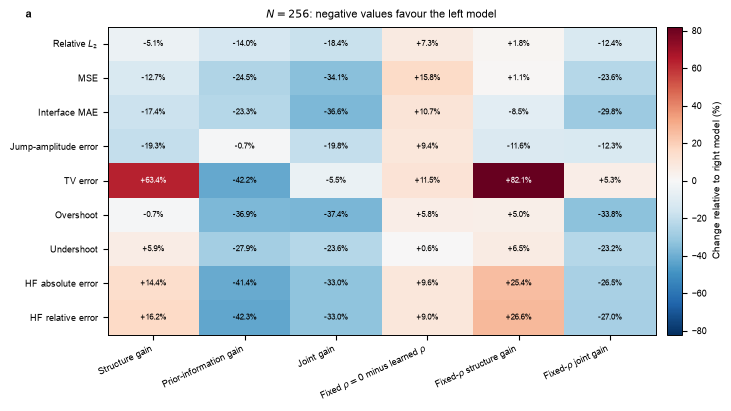

In [6]:
heatmap = bootstrap_frame[(bootstrap_frame.resolution == 256)].pivot(index="metric_label", columns="contrast_label", values="percent_change")
heatmap = heatmap.reindex([label for _, label in METRICS], columns=[item[3] for item in CONTRASTS])
heatmap_values = heatmap.to_numpy(dtype=float)
limit = max(1.0, float(np.nanmax(np.abs(heatmap_values))))
figure, axis = plt.subplots(figsize=(7.2, 4.0), constrained_layout=True)
image = axis.imshow(heatmap_values, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit), aspect="auto")
axis.set_xticks(np.arange(heatmap_values.shape[1]), heatmap.columns, rotation=25, ha="right")
axis.set_yticks(np.arange(heatmap_values.shape[0]), heatmap.index)
for row in range(heatmap_values.shape[0]):
    for column in range(heatmap_values.shape[1]):
        axis.text(column, row, f"{heatmap_values[row, column]:+.1f}%", ha="center", va="center", fontsize=6, color="white" if abs(heatmap_values[row, column]) > 0.55 * limit else "black")
figure.colorbar(image, ax=axis, label="Change relative to right model (%)", fraction=0.035, pad=0.02)
axis.set_title(r"$N=256$: negative values favour the left model")
axis.text(-0.15, 1.03, "a", transform=axis.transAxes, fontweight="bold", fontsize=8)
export_figure(figure, "figure3_metric_heatmap")
plt.show()
heatmap.to_csv(source_dir / "figure3_metric_heatmap.csv")


## 8. 图 4：透明规则选择的代表性解场


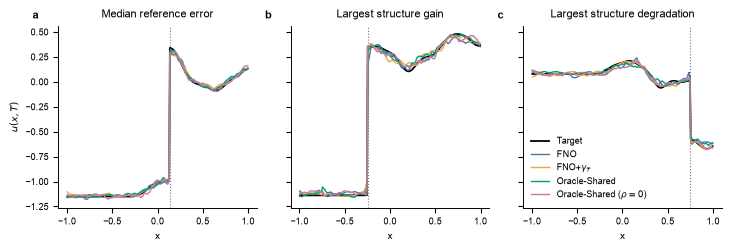

In [7]:
relative_index = [key for key, _ in METRICS].index("relative_l2")
primary_difference = metric_data[256]["shared_oracle"][:, :, relative_index] - metric_data[256]["fno_gamma"][:, :, relative_index]
mean_difference = np.mean(primary_difference, axis=0)
mean_reference = np.mean(metric_data[256]["fno_gamma"][:, :, relative_index], axis=0)
median_index = int(np.argmin(np.abs(mean_reference - np.median(mean_reference))))
best_index = int(np.argmin(mean_difference))
worst_index = int(np.argmax(mean_difference))
selected = [(median_index, "Median reference error"), (best_index, "Largest structure gain"), (worst_index, "Largest structure degradation")]

with np.load(run_dir("fno", 0) / "predictions_n256.npz", allow_pickle=False) as saved:
    target = np.asarray(saved["target"])
    interface = np.asarray(saved["interface_location"]) + 0.5
x = -1.0 + (np.arange(256) + 0.5) * (2.0 / 256)
figure, axes = plt.subplots(1, 3, figsize=(7.2, 2.4), sharey=True, constrained_layout=True)
profile_rows = []
for panel, (axis, (sample_index, title)) in enumerate(zip(axes, selected, strict=True)):
    axis.plot(x, target[sample_index], color="black", linewidth=1.3, label="Target")
    for model in MODELS:
        predictions = []
        for seed in SEEDS:
            with np.load(run_dir(model, seed) / "predictions_n256.npz", allow_pickle=False) as saved:
                predictions.append(np.asarray(saved["prediction"])[sample_index])
        mean_prediction = np.mean(predictions, axis=0)
        axis.plot(x, mean_prediction, color=COLORS[model], linewidth=1.0, label=MODEL_LABELS[model])
        for coordinate, value, target_value in zip(x, mean_prediction, target[sample_index], strict=True):
            profile_rows.append({"panel": panel, "selection": title, "sample_index": sample_index, "model": model, "x": coordinate, "prediction": value, "target": target_value})
    axis.axvline(interface[sample_index], color="#777777", linestyle=":", linewidth=0.8)
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.spines[["top", "right"]].set_visible(False)
    axis.text(-0.13, 1.04, chr(ord("a") + panel), transform=axis.transAxes, fontweight="bold", fontsize=8)
axes[0].set_ylabel(r"$u(x,T)$")
axes[-1].legend(frameon=False, loc="best")
export_figure(figure, "figure4_representative_profiles")
plt.show()
pd.DataFrame(profile_rows).to_csv(source_dir / "figure4_representative_profiles.csv", index=False)


## 9. 图 5：可学习 $ho_{ij}^{\ell}$ 及固定 $ho=0$ 参照


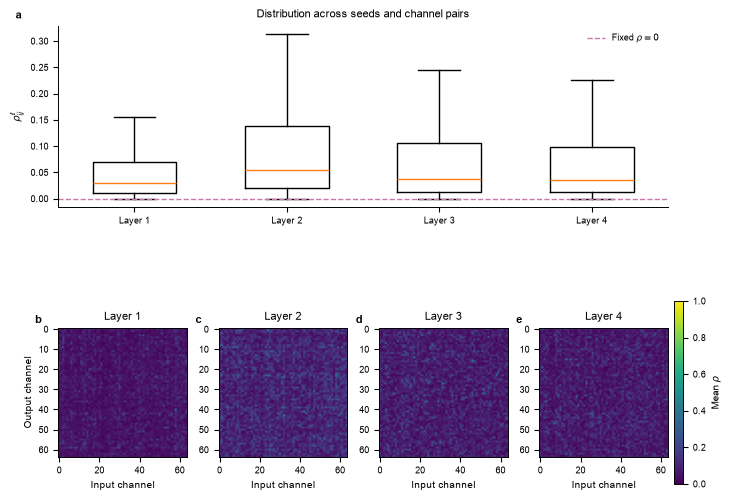

In [8]:
rho_by_layer = {layer: [] for layer in range(1, 5)}
rho_rows = []
for seed in SEEDS:
    with np.load(run_dir("shared_oracle", seed) / "rho_layers.npz", allow_pickle=False) as saved:
        for layer in range(1, 5):
            values = np.asarray(saved[f"layer_{layer}"], dtype=np.float64)
            rho_by_layer[layer].append(values)
            flat = values.ravel()
            rho_rows.append({
                "seed": seed, "layer": layer, "mean": flat.mean(), "std": flat.std(),
                "q05": np.quantile(flat, 0.05), "median": np.median(flat), "q95": np.quantile(flat, 0.95),
                "near_zero_fraction": np.mean(flat < 1e-3), "near_one_fraction": np.mean(flat > 1 - 1e-3),
            })

figure = plt.figure(figsize=(7.2, 5.5), constrained_layout=True)
grid = figure.add_gridspec(2, 4, height_ratios=[0.8, 1.4])
axis_box = figure.add_subplot(grid[0, :])
box_values = [np.concatenate([value.ravel() for value in rho_by_layer[layer]]) for layer in range(1, 5)]
axis_box.boxplot(
    box_values,
    tick_labels=[f"Layer {layer}" for layer in range(1, 5)],
    showfliers=False,
    widths=0.55,
)
axis_box.axhline(0.0, color=COLORS["shared_oracle_rho0"], linestyle="--", linewidth=1.0, label=r"Fixed $\rho=0$")
axis_box.set_ylabel(r"$\rho_{ij}^{\ell}$")
axis_box.set_title("Distribution across seeds and channel pairs")
axis_box.legend(frameon=False, loc="upper right")
axis_box.spines[["top", "right"]].set_visible(False)
axis_box.text(-0.07, 1.04, "a", transform=axis_box.transAxes, fontweight="bold", fontsize=8)
for layer in range(1, 5):
    axis = figure.add_subplot(grid[1, layer - 1])
    matrix = np.mean(np.stack(rho_by_layer[layer], axis=0), axis=0)
    image = axis.imshow(matrix, vmin=0.0, vmax=1.0, cmap="viridis", rasterized=True)
    axis.set_title(f"Layer {layer}")
    axis.set_xlabel("Input channel")
    if layer == 1:
        axis.set_ylabel("Output channel")
    axis.text(-0.18, 1.04, chr(ord("b") + layer - 1), transform=axis.transAxes, fontweight="bold", fontsize=8)
figure.colorbar(image, ax=figure.axes[1:], fraction=0.015, pad=0.01, label=r"Mean $\rho$")
export_figure(figure, "figure5_rho_diagnostics")
plt.show()
pd.DataFrame(rho_rows).to_csv(source_dir / "figure5_rho_summary.csv", index=False)


## 10. 图 6：预注册子组


hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

hierarchical bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

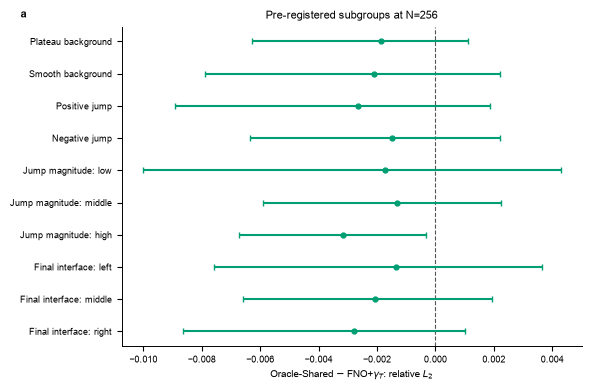

,subgroup,n_samples,contrast,contrast_label,difference,lower_95,upper_95
0,Plateau background,756,shared_oracle_minus_fno_gamma,Structure gain,-0.001871,-0.006281,0.001109
1,Plateau background,756,fno_gamma_minus_fno,Prior-information gain,-0.005538,-0.007694,-0.003342
2,Plateau background,756,shared_oracle_minus_fno,Joint gain,-0.007409,-0.010352,-0.005138
3,Plateau background,756,shared_oracle_rho0_minus_shared_oracle,Fixed $\rho=0$ minus learned $\rho$,0.000876,-0.000383,0.001898
4,Plateau background,756,shared_oracle_rho0_minus_fno_gamma,Fixed-$\rho$ structure gain,-0.000995,-0.004897,0.001791
5,Plateau background,756,shared_oracle_rho0_minus_fno,Fixed-$\rho$ joint gain,-0.006533,-0.009027,-0.003810
6,Smooth background,3244,shared_oracle_minus_fno_gamma,Structure gain,-0.002119,-0.007908,0.002210
7,Smooth background,3244,fno_gamma_minus_fno,Prior-information gain,-0.006887,-0.010327,-0.003708
8,Smooth background,3244,shared_oracle_minus_fno,Joint gain,-0.009006,-0.012470,-0.006474
9,Smooth background,3244,shared_oracle_rho0_minus_shared_oracle,Fixed $\rho=0$ minus learned $\rho$,0.003266,0.001658,0.004896


In [9]:
with np.load(run_dir("fno", 0) / "predictions_n256.npz", allow_pickle=False) as saved:
    jump = np.asarray(saved["jump"], dtype=float)
    final_interface = np.asarray(saved["interface_location"], dtype=float) + 0.5
    plateau = np.asarray(saved["plateau"], dtype=bool)

subgroups = {
    "Plateau background": plateau,
    "Smooth background": ~plateau,
    "Positive jump": jump > 0,
    "Negative jump": jump < 0,
    "Jump magnitude: low": (np.abs(jump) >= 0.5) & (np.abs(jump) < 5/6),
    "Jump magnitude: middle": (np.abs(jump) >= 5/6) & (np.abs(jump) < 7/6),
    "Jump magnitude: high": (np.abs(jump) >= 7/6) & (np.abs(jump) <= 1.5),
    "Final interface: left": (final_interface >= -0.25) & (final_interface < 1/12),
    "Final interface: middle": (final_interface >= 1/12) & (final_interface < 5/12),
    "Final interface: right": (final_interface >= 5/12) & (final_interface <= 0.75),
}
subgroup_rows = []
for subgroup_index, (subgroup, mask) in enumerate(subgroups.items()):
    subgroup_values = np.stack(
        [metric_data[256][model][:, mask, 0] for model in MODELS], axis=-1
    )
    subgroup_means, subgroup_estimates = hierarchical_bootstrap_many(
        subgroup_values,
        repetitions=BOOTSTRAP_REPETITIONS,
        seed=303000 + subgroup_index,
        chunk_size=50,
    )
    for contrast_index, (contrast_name, left, right, contrast_label) in enumerate(CONTRASTS):
        left_index = model_index[left]
        right_index = model_index[right]
        difference = subgroup_means[left_index] - subgroup_means[right_index]
        bootstrap_difference = (
            subgroup_estimates[:, left_index] - subgroup_estimates[:, right_index]
        )
        interval = np.nanquantile(bootstrap_difference, [0.025, 0.975])
        subgroup_rows.append({
            "subgroup": subgroup, "n_samples": int(mask.sum()), "contrast": contrast_name,
            "contrast_label": contrast_label, "difference": float(difference),
            "lower_95": float(interval[0]), "upper_95": float(interval[1]),
        })
subgroup_frame = pd.DataFrame(subgroup_rows)
subgroup_frame.to_csv(source_dir / "subgroup_contrasts.csv", index=False)

primary_subgroups = subgroup_frame[subgroup_frame.contrast == "shared_oracle_minus_fno_gamma"]
figure, axis = plt.subplots(figsize=(5.8, 3.8), constrained_layout=True)
y = np.arange(len(primary_subgroups))
axis.axvline(0, color="#555555", linestyle="--", linewidth=0.8)
axis.errorbar(primary_subgroups.difference, y, xerr=np.vstack([primary_subgroups.difference-primary_subgroups.lower_95, primary_subgroups.upper_95-primary_subgroups.difference]), fmt="o", color=COLORS["shared_oracle"], capsize=2.2, markersize=3.5)
axis.set_yticks(y, primary_subgroups.subgroup)
axis.invert_yaxis()
axis.set_xlabel(r"Oracle-Shared $-$ FNO+$\gamma_T$: relative $L_2$")
axis.set_title("Pre-registered subgroups at N=256")
axis.spines[["top", "right"]].set_visible(False)
axis.text(-0.22, 1.03, "a", transform=axis.transAxes, fontweight="bold", fontsize=8)
export_figure(figure, "figure6_preregistered_subgroups")
plt.show()
display(subgroup_frame)


## 11. 中文报告、比较 manifest 与 QA

自动报告逐一解释六幅图和全部 source-data 表，并明确区分预注册主要/次要结果与后注册固定 $\rho=0$ 消融。最后检查所有导出文件、SVG 可编辑文字、CSV 和 manifest。


In [10]:
def interval_conclusion(row):
    if row["upper_95"] < 0:
        return "前者误差更低，且 95% 区间未跨 0"
    if row["lower_95"] > 0:
        return "前者误差更高，且 95% 区间未跨 0"
    return "95% 区间跨 0，当前证据不足以区分"

summary_rows = []
for model in MODELS:
    for seed in SEEDS:
        for resolution in RESOLUTIONS:
            row = dict(summary_lookup[(model, seed, resolution)])
            row.update({"model": model, "seed": seed, "resolution": resolution})
            summary_rows.append(row)
pd.DataFrame(summary_rows).to_csv(source_dir / "summary_by_seed.csv", index=False)

resolution_frame = pd.DataFrame(resolution_rows)
resolution_summary = (
    resolution_frame.groupby(["model", "resolution"])["relative_l2_mean"]
    .mean()
    .reset_index()
)
resolution_winners = []
for resolution in RESOLUTIONS:
    selected_resolution = resolution_summary[resolution_summary.resolution == resolution]
    winner = selected_resolution.loc[selected_resolution.relative_l2_mean.idxmin()]
    resolution_winners.append(
        f"N={resolution} 时 {MODEL_LABELS[winner['model']]} 的五 seed 均值最低（{winner['relative_l2_mean']:.6e}）"
    )
largest_heatmap_position = np.unravel_index(
    np.nanargmax(np.abs(heatmap_values)), heatmap_values.shape
)
largest_heatmap_metric = heatmap.index[largest_heatmap_position[0]]
largest_heatmap_contrast = heatmap.columns[largest_heatmap_position[1]]
largest_heatmap_value = heatmap_values[largest_heatmap_position]
rho_frame = pd.DataFrame(rho_rows)
rho_layer_means = rho_frame.groupby("layer")["mean"].mean()
rho_saturation = rho_frame.assign(
    saturation=lambda frame: frame.near_zero_fraction + frame.near_one_fraction
).groupby("layer")["saturation"].mean()
primary_subgroup_best = primary_subgroups.loc[primary_subgroups.difference.idxmin()]
primary_subgroup_worst = primary_subgroups.loc[primary_subgroups.difference.idxmax()]

figure_explanations = {
    "图 1": "森林图包含四模型全部六组两两比较；前三组属于原 v2 协议，后三组是固定 rho=0 的后注册消融。"
    + "；".join(
        f"{row.contrast_label} 的差值为 {row.difference:.6e}，95% 区间为 [{row.lower_95:.6e}, {row.upper_95:.6e}]"
        for row in primary_rows.itertuples()
    )
    + "。负值表示左侧模型误差更低。",
    "图 2": "四模型均使用 N=256 训练得到的最优 checkpoint，在更细网格上不微调推理。"
    + "；".join(resolution_winners)
    + "。误差线为五 seed 标准差。",
    "图 3": f"热图汇总 N=256 的九项误差指标相对变化。绝对变化最大的单元为 {largest_heatmap_contrast} 的 {largest_heatmap_metric}（{largest_heatmap_value:+.2f}%）；负百分比表示左侧模型相对右侧模型降低误差，正式区间见 bootstrap 表。",
    "图 4": f"代表性样本由固定规则自动选择，样本索引依次为 {median_index}、{best_index}、{worst_index}；对应结构差值分别为 {mean_difference[median_index]:.6e}、{mean_difference[best_index]:.6e}、{mean_difference[worst_index]:.6e}。曲线为五 seed 预测均值，不能替代总体统计。",
    "图 5": "各层 rho 的 seed 平均值为 "
    + "、".join(f"第 {layer} 层 {value:.4f}" for layer, value in rho_layer_means.items())
    + "；接近 0 或 1 的平均饱和比例为 "
    + "、".join(f"第 {layer} 层 {value:.2%}" for layer, value in rho_saturation.items())
    + "。热图进一步显示通道对结构；紫色虚线给出后注册固定 rho=0 消融的确定性参照。",
    "图 6": f"预注册子组中，主比较均值差最小的是 {primary_subgroup_best.subgroup}（{primary_subgroup_best.difference:.6e}），最大的是 {primary_subgroup_worst.subgroup}（{primary_subgroup_worst.difference:.6e}）。子组结论仍应结合各自 95% 区间和样本量。",
}

table_explanations = {
    "formal_protocol_v2.csv": "汇总本次正式实验的实际协议、数据范围、模型配置和优化设置；该表用于核对报告中所有训练与数据描述。",
    "main_results_table.csv": "主分辨率 $N=256$ 的六项两两相对 $L_2$ 对比，含两侧均值、配对差、95% 区间和百分比变化；它是图 1 的精确数值来源。",
    "superresolution_summary.csv": "四模型在 $N=256/512/1024$ 的五 seed 相对 $L_2$ 均值和标准差；它是图 2 的精确数值来源。",
    "artifact_audit.csv": "记录 20 个模型×seed 训练单元的协议、history、checkpoint、gamma 完整性与 rho 策略审计。",
    "summary_by_seed.csv": "保留四模型、五 seed、三分辨率的全部汇总指标，是跨 seed 描述统计的来源。",
    "paired_hierarchical_bootstrap.csv": "保存主分辨率九项指标及超分辨率相对 L2 的配对差值、95% 区间和相对变化。",
    "figure1_primary_contrasts.csv": "图 1 的六项两两相对 L2 对比及其区间。",
    "figure2_superresolution.csv": "图 2 的逐模型、逐 seed、逐分辨率相对 L2。",
    "figure3_metric_heatmap.csv": "图 3 的九指标相对变化矩阵。",
    "subgroup_contrasts.csv": "保存全部预注册子组、六项对比的样本量、均值差和 95% 区间；固定 rho=0 相关行属于后注册消融。",
    "figure5_rho_summary.csv": "保存每个 seed、每层 rho 的均值、标准差、分位数与接近 0/1 的饱和比例。",
    "figure4_representative_profiles.csv": "保存透明规则选出的样本、网格坐标、目标和四模型五 seed 平均预测。",
    "figure_qa.csv": "记录每幅图四种导出格式的文件大小和 SVG 可编辑文字检查。",
}

primary = primary_rows.iloc[0].to_dict()
reference_manifest = read_json(seed_dir("shared_oracle", 0) / "manifest.json")
data_config = reference_manifest["data_config"]
model_config = reference_manifest["model_config"]
training_config = reference_manifest["training_config"]

formal_protocol_rows = [
    ("协议版本与运行标签", f"v{reference_manifest['protocol_version']} / {reference_manifest['run_tag']}"),
    ("空间区域与训练分辨率", f"[{data_config['x_min']}, {data_config['x_max']}] / $N={reference_manifest['n_x']}$"),
    ("初态界面位置", f"$\\xi_0 \\in [{data_config['v2_interface_low']}, {data_config['v2_interface_high']}]$"),
    ("输运设置", f"速度 {data_config['velocity']}，终止时间 {data_config['final_time']}，故 $\\xi_T=\\xi_0+{data_config['velocity'] * data_config['final_time']}$"),
    ("跳跃与背景", f"所有样本内部非零跳跃，$|[u]| \\in [{data_config['jump_abs_low']}, {data_config['jump_abs_high']}]$；平台背景比例 {data_config['plateau_fraction']:.0%}"),
    ("数据划分（每个 seed）", f"训练 {reference_manifest['sizes']['train']:,} / 验证 {reference_manifest['sizes']['validation']:,} / 测试 {reference_manifest['sizes']['test']:,}"),
    ("训练与推理网格", "$N=256$ 训练；最优 checkpoint 在 $N=256,512,1024$ 直接推理"),
    ("随机重复", f"训练 seed {', '.join(map(str, reference_manifest['seeds']))}（共 {len(reference_manifest['seeds'])} 个）"),
    ("共同网络主干", f"{model_config['n_layers']} 个谱层，隐藏通道 {model_config['hidden_channels']}，谱模态 {model_config['n_modes']}，lifting/projection 通道 {model_config['lifting_channels']}/{model_config['projection_channels']}，padding={model_config['pad_fraction']}"),
    ("优化", f"AdamW；学习率 {training_config['learning_rate']:.0e}，权重衰减 {training_config['weight_decay']:.0e}，batch size {training_config['batch_size']}，梯度裁剪 {training_config['gradient_clip']}"),
    ("学习率日程", f"线性 warm-up 占 {training_config['warmup_fraction']:.0%}，末端学习率比例 {training_config['end_learning_rate_fraction']:.0%}"),
    ("训练与 checkpoint", f"固定 {training_config['epochs']} epoch；无早停；每 {reference_manifest['runtime_controls']['checkpoint_every']} epoch 保存；正式推理读取验证相对 $L_2$ 最优 checkpoint"),
    ("损失", "仅解场 MSE；$\\gamma$ 损失关闭"),
    ("FNO 输入", "3 通道：初态解场及坐标特征"),
    ("FNO+$\\gamma_T$ 输入", "4 通道：FNO 输入加已知解析终态界面 $\\gamma_T$"),
    ("Oracle-Shared", "4 通道 lifting；固定门控序列 $[\\gamma_0,\\gamma_T,\\gamma_T,\\gamma_T,\\gamma_T]$；无 $\\gamma$ 递推网络和 $\\gamma$ 损失"),
    ("Oracle-Shared（固定 $\\rho=0$）", "与 Oracle-Shared 使用相同四通道输入和固定门控，但所有层、所有通道对均固定 $\\rho_{ij}^{\\ell}=0$，即 $a_{ij}^{\\ell}=b_{ij}^{\\ell}=0.5$；参数树中无 `rho_eta`"),
]
formal_protocol_frame = pd.DataFrame(formal_protocol_rows, columns=["项目", "实际设置"])
formal_protocol_frame.to_csv(source_dir / "formal_protocol_v2.csv", index=False)

main_results = primary_rows[["contrast_label", "left_model", "right_model", "left_mean", "right_mean", "difference", "lower_95", "upper_95", "percent_change", "repetitions"]].copy()
main_results["left_model"] = main_results["left_model"].map(MODEL_LABELS)
main_results["right_model"] = main_results["right_model"].map(MODEL_LABELS)
main_results.to_csv(source_dir / "main_results_table.csv", index=False)

superresolution_summary = (
    resolution_frame.groupby(["model", "resolution"])["relative_l2_mean"]
    .agg(mean="mean", std="std")
    .reset_index()
)
superresolution_summary["model"] = superresolution_summary["model"].map(MODEL_LABELS)
superresolution_summary.to_csv(source_dir / "superresolution_summary.csv", index=False)

def markdown_table(headers, rows):
    return [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
        *["| " + " | ".join(map(str, row)) + " |" for row in rows],
    ]

def metric_direction(row):
    return "前者更低" if row["difference"] < 0 else "前者更高"

primary_table_rows = [
    (
        row.contrast_label,
        f"{row.left_mean:.5f}",
        f"{row.right_mean:.5f}",
        f"{row.difference:+.5f}",
        f"[{row.lower_95:+.5f}, {row.upper_95:+.5f}]",
        f"{row.percent_change:+.1f}%",
    )
    for row in primary_rows.itertuples()
]
superresolution_table_rows = [
    (
        int(resolution),
        *[
            f"{row.mean:.5f} $\\pm$ {row.std:.5f}"
            for row in superresolution_summary[superresolution_summary.resolution == resolution].itertuples()
        ],
    )
    for resolution in RESOLUTIONS
]

main_metric_rows = bootstrap_frame[(bootstrap_frame.resolution == 256) & (bootstrap_frame.contrast == "shared_oracle_minus_fno_gamma")].copy()
main_metric_rows = main_metric_rows.set_index("metric")
information_gain = primary_rows[primary_rows.contrast == "fno_gamma_minus_fno"].iloc[0]
joint_gain = primary_rows[primary_rows.contrast == "shared_oracle_minus_fno"].iloc[0]
rho_ablation = primary_rows[
    primary_rows.contrast == "shared_oracle_rho0_minus_shared_oracle"
].iloc[0]
fixed_rho_structure = primary_rows[
    primary_rows.contrast == "shared_oracle_rho0_minus_fno_gamma"
].iloc[0]
fixed_rho_joint = primary_rows[
    primary_rows.contrast == "shared_oracle_rho0_minus_fno"
].iloc[0]
primary_supported = primary["upper_95"] < 0
primary_interpretation = (
    "该区间未跨 0，支持固定门控的额外结构增益。"
    if primary_supported
    else "该区间跨 0，因而本次结果不能证明固定门控相对仅提供 gamma_T 有额外的总体相对 L2 优势。"
)

report_lines = [
    "# Deep FNO / Shared Benchmark v2 四模型对比测试报告",
    "",
    "## 1. 技术摘要",
    "",
    "本实验回答两个受控问题：在所有样本均含内部间断、且终态界面 $\\gamma_T$ 已知的条件下，性能提升究竟来自于**提供 $\\gamma_T$**，还是来自于进一步把 $\\gamma_T$ 写入 Oracle-Shared 的固定门控结构；在 Oracle-Shared 内部，可学习 $\\rho$ 是否优于固定等权 $\\rho=0$。四种模型使用相同数据、主干配置、优化设置、五个训练 seed 和完全配对的测试样本。前三模型及其主次比较沿用原 v2 协议，固定 $\\rho=0$ 模型明确作为后注册消融解释。",
    "",
    f"主终点为 $N=256$ 的逐样本相对 $L_2$。Oracle-Shared 相对 FNO+$\\gamma_T$ 的均值差为 {primary['difference']:+.6e}（95% 分层配对 bootstrap 区间 [{primary['lower_95']:+.6e}, {primary['upper_95']:+.6e}]，{primary['percent_change']:+.2f}%）。{primary_interpretation}",
    "",
    f"相比之下，FNO+$\\gamma_T$ 相对 FNO 的均值差为 {information_gain.difference:+.6e}（95% 区间 [{information_gain.lower_95:+.6e}, {information_gain.upper_95:+.6e}]），而 Oracle-Shared 相对 FNO 的联合差值为 {joint_gain.difference:+.6e}（95% 区间 [{joint_gain.lower_95:+.6e}, {joint_gain.upper_95:+.6e}]）。因此，应把结论拆开表述：$\\gamma_T$ 先验的贡献由第二项衡量；固定门控的附加贡献仅由主比较衡量。",
    "",
    f"后注册的 $\\rho$ 消融中，固定 $\\rho=0$ 的 Oracle-Shared 相对可学习 $\\rho$ 的 Oracle-Shared 均值差为 {rho_ablation.difference:+.6e}（95% 区间 [{rho_ablation.lower_95:+.6e}, {rho_ablation.upper_95:+.6e}]）。固定 $\\rho=0$ 相对 FNO+$\\gamma_T$ 和 FNO 的差值分别为 {fixed_rho_structure.difference:+.6e} 与 {fixed_rho_joint.difference:+.6e}。这些结果用于解释共享混合系数的作用，不改变原 v2 主终点的定义。",
    "",
    "## 2. 问题、数据与对照设计",
    "",
    "### 2.1 研究问题与可比性",
    "",
    "目标是学习一维线性输运下由初态解场到终态解场的算子。为避免 v1 中连续样本稀释问题，本协议只保留区域内部的非零间断：初态界面 $\\xi_0$ 被限制在 $[-0.75, 0.25]$，速度为 $0.5$、终止时间为 $1$，故终态界面 $\\xi_T=\\xi_0+0.5\\in[-0.25,0.75]$，不会越过区域边界。背景仍混合平滑与平台两类，从而考察模型在不同背景上的间断保持能力。",
    "",
    "### 2.2 表 1：正式实验实际设置",
    "",
    "表 1 汇总实际写入正式 run manifest 的数据、网络和优化设置，而不是计划值。前三模型的设计差异是是否使用已知 $\\gamma_T$ 以及是否将其用于固定门控；第四模型进一步把所有 $\\rho_{ij}^{\\ell}$ 固定为 0。完整机器可读版本见 `source_data/formal_protocol_v2.csv`。",
    "",
    *markdown_table(["项目", "实际设置"], formal_protocol_frame.itertuples(index=False, name=None)),
    "",
    "### 2.3 模型对照",
    "",
    "- **FNO**：三通道基线，不接收终态界面。",
    "- **FNO+$\\gamma_T$**：与 FNO 同一主干，只把解析的已知终态界面作为第四输入通道；它量化先验信息本身的价值。",
    "- **Oracle-Shared**：同样接收第四通道，但在四个谱层中使用固定门控序列 $[\\gamma_0,\\gamma_T,\\gamma_T,\\gamma_T,\\gamma_T]$。该模型不含 $\\gamma$ 递推块，不预测 $\\gamma$，也不使用 $\\gamma$ 损失；它量化已知界面被结构化使用后的额外价值。",
    "- **Oracle-Shared（固定 $\\rho=0$）**：门控和输入与 Oracle-Shared 相同，但所有通道对固定 $a_{ij}^{\\ell}=b_{ij}^{\\ell}=0.5$，没有可训练 `rho_eta`。它是后注册消融，用于检验可学习混合系数是否有额外价值。",
    "",
    "## 3. 评价与统计方法",
    "",
    "每个 seed 的测试集含 4,000 个样本，四模型在每个分辨率上使用相同样本 ID、目标和解析 $\\gamma_T$；审计已验证输入 $\\gamma_T$ 与目标 $\\gamma_T$ 完全一致，两个 Oracle 模型的门控误差均为 0，固定 $\\rho=0$ 模型的参数树中不存在 `rho_eta` 且诊断矩阵严格为零。正式推理读取验证集相对 $L_2$ 最小的 checkpoint；每次运行均训练满 500 epoch，因此最佳轮次可能早于第 500 轮，但不构成早停。",
    "",
    "主终点仍是原协议定义的 $N=256$ 逐样本相对 $L_2$，主比较为 Oracle-Shared−FNO+$\\gamma_T$；原协议次要比较为 FNO+$\\gamma_T$−FNO 和 Oracle-Shared−FNO。固定 $\\rho=0$ 相关的三项对比均标记为后注册消融。差值统一为“左模型减右模型”，所以负值表示左模型更好。补充指标包括 MSE、界面 MAE、跳跃幅值误差、总变差误差、过冲、欠冲及高频误差。置信区间通过 10,000 次分层配对 bootstrap 计算：先重抽训练 seed，再在每个被抽 seed 内重抽同一测试样本。",
    "",
    "## 4. 主结果：先验信息与固定门控应分开解释",
    "",
    "### 4.1 表 2：主终点的精确数值",
    "",
    "表 2 给出图 1 的数值来源。均值在五个 seed 和全部配对测试样本上计算；95% 区间针对均值差。它用于判断总体证据：只有区间不跨 0 的误差差值才能作为该对比下稳定的方向性证据。",
    "",
    *markdown_table(["对比（左−右）", "左侧均值", "右侧均值", "差值", "95% 区间", "相对变化"], primary_table_rows),
    "",
    "### 4.2 图 1：四模型六项两两相对 $L_2$ 对比的森林图",
    "",
    "![图 1：主终点的分层配对 bootstrap 对比](figures/figure1_primary_contrasts.png)",
    "",
    figure_explanations["图 1"],
    "横轴为配对误差差，虚线为零差。前三行对应原 v2 主比较和两项次要比较；后三行对应固定 $\\rho=0$ 的后注册消融。最直接的 $\\rho$ 证据是“Fixed $\\rho=0$ minus learned $\\rho$”：负值支持固定等权共享，正值支持可学习 $\\rho$。",
    "",
    "### 4.3 图 2 与表 3：零样本超分辨率",
    "",
    "![图 2：$N=256$ 训练模型的零样本超分辨率](figures/figure2_superresolution.png)",
    "",
    figure_explanations["图 2"],
    "图 2 的点是五个 seed 的平均相对 $L_2$，误差线为 seed 间标准差。分辨率变化仅改变推理网格，不进行高分辨率再训练或微调；因此它衡量的是训练网格之外的算子泛化，而不是重训后的高分辨率性能。",
    "",
    *markdown_table(["推理分辨率", "FNO", "FNO+$\\gamma_T$", "Oracle-Shared", "Oracle-Shared（$\\rho=0$）"], superresolution_table_rows),
    "",
    "表 3 给出图 2 的精确均值 $\\pm$ seed 标准差。它用于查看误差随网格加密的幅度与模型排序；严格的模型间差异区间仍应查阅 `source_data/paired_hierarchical_bootstrap.csv` 中对应分辨率的配对 bootstrap 行。",
    "",
    "## 5. 多指标、样本与机制诊断",
    "",
    "### 5.1 图 3：九项误差指标的相对变化",
    "",
    "![图 3：$N=256$ 的九指标相对变化热图](figures/figure3_metric_heatmap.png)",
    "",
    figure_explanations["图 3"],
    "热图将每个误差指标标准化为相对右侧模型的百分比变化，便于在量纲不同的指标间浏览方向与幅度。颜色和单元格中的负值都代表左侧模型误差更低；它是补充诊断而非新的主终点，单元格的正式不确定性应由同名 bootstrap 表行判断。",
    "",
    "### 5.2 图 4：规则选择的代表性解剖面",
    "",
    "![图 4：代表性样本的目标和模型预测剖面](figures/figure4_representative_profiles.png)",
    "",
    figure_explanations["图 4"],
    "三栏依次展示参考误差居中的样本、原协议结构增益最大的样本和结构退化最大的样本。样本通过固定的、可复现规则选择，每栏同时绘制四模型的五 seed 平均预测；该图帮助观察界面附近的平滑、跳跃和过冲形态，但不能替代图 1 的总体推断。对应逐网格数值见 `source_data/figure4_representative_profiles.csv`。",
    "",
    "### 5.3 图 5：$\\rho$ 层间诊断",
    "",
    "![图 5：Oracle-Shared 的 $\\rho$ 分布与逐层热图](figures/figure5_rho_diagnostics.png)",
    "",
    figure_explanations["图 5"],
    "图 5 描述可学习 Oracle-Shared 中 $\\rho$ 混合系数在各层和通道对上的经验分布，并以紫色虚线给出固定 $\\rho=0$ 模型的确定性参照。性能因果判断应结合图 1 中固定 $\\rho=0$−可学习 $\\rho$ 的配对消融，而不能只根据参数分布作结论。",
    "",
    "### 5.4 图 6：预注册子组的一致性",
    "",
    "![图 6：预注册子组中的主比较](figures/figure6_preregistered_subgroups.png)",
    "",
    figure_explanations["图 6"],
    "子组在分析前按平台/平滑背景、跳跃符号、跳跃幅值（低/中/高）和终态界面位置（左/中/右）定义。每个点仍是 Oracle-Shared−FNO+$\\gamma_T$ 的配对相对 $L_2$ 差，横线为其 95% 分层 bootstrap 区间。该图用于判断方向是否明显依赖某一预设条件；子组样本量减少且未以子组检验取代主终点，因此不应据此作过强的细分结论。",
    "",
    "## 6. 表格、source data 与可复现性",
    "",
    "所有定量图均同时导出 SVG、PDF、600 dpi TIFF 和 300 dpi PNG；SVG 的可编辑文字和所有导出文件的非空状态已经审计。四模型结果写入独立的 `comparison_four_models` 目录，不覆盖原三模型报告。以下 source-data 表与比较 manifest 使图表、统计和正式训练产物可追溯：",
    "",
]
for name, explanation in table_explanations.items():
    report_lines.extend([f"- `{name}`：{explanation}"])
report_lines.extend([
    "",
    "## 7. 解释边界、稳健性与下一步",
    "",
    "- **主结论的边界**：原 v2 主结论只以 $N=256$ 的 Oracle-Shared−FNO+$\\gamma_T$ 及其分层配对区间为准。固定 $\\rho=0$ 的结果属于后注册消融，应与主终点分开表述。",
    "- **先验假设**：Oracle-Shared 和 FNO+$\\gamma_T$ 均获得解析且无误差的 $\\gamma_T$。因此结果回答的是“已知终态界面如何被使用”，不能外推到必须预测或测量 $\\gamma_T$ 的情形。",
    "- **超分辨率解释**：$N=512$ 与 $N=1024$ 是零样本推理；它们支持或限制离散化泛化的判断，但不等同于在高分辨率数据上训练后的最佳可达性能。",
    "- **统计范围**：五个训练 seed 与 4,000 个配对测试样本覆盖了本协议内的随机性；对其他背景分布、速度、终止时间或二维/更高维问题的外推仍需要新的实验。",
    "- **运行时间**：训练/推理墙钟时间受 GPU、编译、并行负载与 I/O 影响，仅可作为本批运行的描述性信息，不能据此比较算法复杂度。",
    "",
    "建议的下一步是：先根据固定 $\\rho=0$−可学习 $\\rho$ 的配对区间判断学习 $\\rho$ 是否带来稳定收益；如区间跨零，不应仅凭个例或参数热图选择架构。若主比较稳定为负，还应加入带噪或预测的 $\\gamma_T$ 消融，以检验固定门控优势对界面误差的鲁棒性。",
])
report_path = comparison_dir / "four_model_main_v2_comparison_report.md"
report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")

figure_names = (
    "figure1_primary_contrasts", "figure2_superresolution", "figure3_metric_heatmap",
    "figure4_representative_profiles", "figure5_rho_diagnostics", "figure6_preregistered_subgroups",
)
qa_rows = []
for name in figure_names:
    for extension in ("svg", "pdf", "tiff", "png"):
        path = figure_dir / f"{name}.{extension}"
        if not path.is_file() or path.stat().st_size == 0:
            raise RuntimeError(f"图形缺失或为空：{path}")
        editable_text = None
        if extension == "svg":
            editable_text = "<text" in path.read_text(encoding="utf-8")
            if not editable_text:
                raise RuntimeError(f"SVG 文字不可编辑：{path}")
        qa_rows.append({"figure": name, "extension": extension, "bytes": path.stat().st_size, "editable_svg_text": editable_text})
pd.DataFrame(qa_rows).to_csv(comparison_dir / "figure_qa.csv", index=False)

comparison_manifest = {
    "protocol_version": 2,
    "run_tag": "main_v2",
    "models": list(MODELS),
    "seeds": list(SEEDS),
    "resolutions": list(RESOLUTIONS),
    "primary_contrast": "shared_oracle_minus_fno_gamma_relative_l2_at_n256",
    "supplemental_ablation_contrast": "shared_oracle_rho0_minus_shared_oracle_relative_l2_at_n256",
    "supplemental_ablation_status": "post_registered",
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_levels": ["training_seed", "paired_test_sample"],
    "figures": list(figure_names),
    "report": report_path.name,
    "source_data": sorted(path.name for path in source_dir.glob("*.csv")),
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "environment": {"python": platform.python_version(), "numpy": np.__version__, "matplotlib": mpl.__version__},
}
(comparison_dir / "comparison_manifest.json").write_text(json.dumps(comparison_manifest, ensure_ascii=False, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print("报告：", report_path)
print("比较 manifest：", comparison_dir / "comparison_manifest.json")
print("PASS：科研图、source data、中文报告与 QA 产物均已生成。")


报告： D:\A4S\间断问题\deep_fno_shared_benchmark\results\formal_main_v2\comparison_four_models\four_model_main_v2_comparison_report.md
比较 manifest： D:\A4S\间断问题\deep_fno_shared_benchmark\results\formal_main_v2\comparison_four_models\comparison_manifest.json
PASS：科研图、source data、中文报告与 QA 产物均已生成。
